# predicting star ratings from review text using BiLSTM
this notebook builds a bilstm model that predicts the star rating (1-5)
a reviewer gave based on the review text and metadata.

why this is useful:
- auto-rate reviews on platforms that only collect text
- detect mismatches (glowing text but 1 star = accidental click or sarcasm)
- understand what language patterns map to what satisfaction level

architecture:
- branch 1: review text -> embedding -> bilstm
- branch 2: metadata -> dense layers
- merge -> 5-class classification (stars 1-5)

In [ ]:
# install dependencies (run once)
%pip install torch numpy pandas scikit-learn matplotlib --quiet

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, lower, regexp_replace, trim,
    udf, split, explode, count as spark_count
)
from pyspark.sql.types import StringType, ArrayType, IntegerType

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

spark = SparkSession.builder \
    .appName('star_prediction_bilstm') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

print(f'spark version: {spark.version}')

spark version: 4.0.2


In [4]:
cols_to_use = [0,1,2,3,4,5,6,7,8,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

pdf = pd.read_csv(
    r'/content/drive/MyDrive/Big Data/part-00000-5d7d137c-d451-4b65-b9c2-3c3d0bbcd7f8-c000.csv',
    engine='c',
    quotechar='"',
    on_bad_lines='skip',
    usecols=cols_to_use,
)
print(f'raw rows: {len(pdf)}')

numeric_cols = [
    'review_stars', 'useful', 'funny', 'cool', 'word_count',
    'business_stars', 'review_count', 'user_review_count',
    'user_useful', 'user_funny', 'user_cool', 'is_open'
]
for c in numeric_cols:
    pdf[c] = pd.to_numeric(pdf[c], errors='coerce')

sdf = spark.createDataFrame(pdf)

raw rows: 588806


In [5]:
feature_cols = [
    'useful', 'funny', 'cool', 'word_count', 'business_stars',
    'review_count', 'user_review_count', 'user_useful',
    'user_funny', 'user_cool', 'is_open'
]

sdf = sdf.filter(col('review_stars').isin([1.0, 2.0, 3.0, 4.0, 5.0]))
sdf = sdf.dropna(subset=['review_stars', 'text'])
sdf = sdf.dropna(subset=feature_cols)
sdf = sdf.filter(col('business_stars').between(1, 5))
sdf = sdf.filter(col('is_open').isin([0, 1]))
sdf = sdf.filter(col('word_count') > 0)

print(f'clean rows after filtering: {sdf.count()}')
sdf.groupBy('review_stars').count().orderBy('review_stars').show()

clean rows after filtering: 453133
+------------+------+
|review_stars| count|
+------------+------+
|         1.0| 62442|
|         2.0| 32955|
|         3.0| 43563|
|         4.0| 95413|
|         5.0|218760|
+------------+------+



In [6]:
stop_words = set(stopwords.words('english'))
sdf = sdf.withColumn('clean_text',
    trim(
        regexp_replace(
            lower(col('text')),
            r'[^a-z\s]', ''
        )
    )
)

broadcast_stop_words = spark.sparkContext.broadcast(stop_words)

@udf(StringType())
def remove_stopwords(text):
    if text is None:
        return None
    words = [w for w in str(text).split() if w not in broadcast_stop_words.value]
    return ' '.join(words)

sdf = sdf.withColumn('clean_text_no_stopwords', remove_stopwords(col('clean_text')))

print('text columns recreated')
sdf.select('text', 'clean_text', 'clean_text_no_stopwords').show(3, truncate=80)

text columns recreated
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                      clean_text|                                                         clean_text_no_stopwords|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|There are new owners here. Way over priced and food is way below what it was....|there are new owners here way over priced and food is way below what it was s...|new owners way priced food way sloppy cooking french fries tasted like everyt..

star distribution:
+------------+------+
|review_stars| count|
+------------+------+
|         1.0| 62442|
|         2.0| 32955|
|         3.0| 43563|
|         4.0| 95413|
|         5.0|218760|
+------------+------+


total: 453133


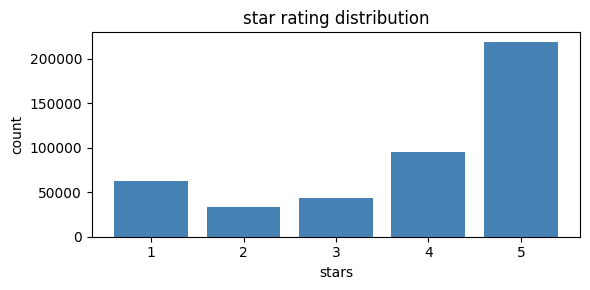

In [7]:
sdf = sdf.withColumn('star_class', (col('review_stars').cast(IntegerType()) - 1))

print('star distribution:')
star_counts = sdf.groupBy('review_stars').count().orderBy('review_stars')
star_counts.show()

print(f'\ntotal: {sdf.count()}')

star_counts_pdf = star_counts.toPandas()

plt.figure(figsize=(6, 3))
plt.bar(star_counts_pdf['review_stars'], star_counts_pdf['count'], color='steelblue')
plt.xlabel('stars')
plt.ylabel('count')
plt.title('star rating distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
sdf = sdf.withColumn('clean_text_no_stopwords',
    trim(regexp_replace(col('clean_text_no_stopwords').cast('string'), 'null', ''))
)
sdf = sdf.fillna({'clean_text_no_stopwords': ''})

word_counts_sdf = (
    sdf.select(explode(split(col('clean_text_no_stopwords'), ' ')).alias('word'))
    .filter(col('word') != '')
    .groupBy('word')
    .agg(spark_count('*').alias('count'))
)

min_freq = 5
filtered_words = (
    word_counts_sdf
    .filter(col('count') >= min_freq)
    .orderBy(col('count').desc())
    .select('word')
    .rdd.flatMap(lambda x: x)
    .collect()
)

vocab = {'<PAD>': 0, '<UNK>': 1}
for idx, word in enumerate(filtered_words, start=2):
    vocab[word] = idx

vocab_size = len(vocab)
print(f'vocab size: {vocab_size}')

vocab size: 47005


In [11]:
max_len = 150

vocab_broadcast = spark.sparkContext.broadcast(vocab)

@udf(ArrayType(IntegerType()))
def text_to_seq_udf(text):
    if text is None:
        text = ''
    words = text.split()[:max_len]
    seq = [vocab_broadcast.value.get(w, 1) for w in words]
    padding = [0] * (max_len - len(seq))
    return seq + padding

sdf = sdf.withColumn('sequence', text_to_seq_udf(col('clean_text_no_stopwords')))

print(f'sequences shape: ({sdf.count()}, {max_len})')

sequences shape: (453133, 150)


In [12]:
pdf = sdf.select(feature_cols + ['star_class', 'sequence']).toPandas()

meta_features = pdf[feature_cols].values.astype(np.float32)
labels = pdf['star_class'].values
num_meta_features = meta_features.shape[1]
num_classes = 5

print(f'metadata shape: {meta_features.shape}')
print(f'labels shape: {labels.shape}')

metadata shape: (453133, 11)
labels shape: (453133,)


In [13]:
agg_exprs = []
for c in feature_cols:
    agg_exprs += [
        F.countDistinct(col(c)).alias(f'{c}__unique'),
        F.min(col(c)).alias(f'{c}__min'),
        F.max(col(c)).alias(f'{c}__max'),
    ]

stats_row = sdf.agg(*agg_exprs).first()

for c in feature_cols:
    print(f'{c}: {stats_row[f"{c}__unique"]} unique values | '
          f'min: {stats_row[f"{c}__min"]} | '
          f'max: {stats_row[f"{c}__max"]}')

useful: 144 unique values | min: 0.0 | max: 840.0
funny: 105 unique values | min: 0.0 | max: 347.0
cool: 134 unique values | min: 0.0 | max: 399.0
word_count: 455 unique values | min: 3.0 | max: 499.0
business_stars: 9 unique values | min: 1.0 | max: 5.0
review_count: 1158 unique values | min: 5.0 | max: 7568.0
user_review_count: 928 unique values | min: 0.0 | max: 6766.0
user_useful: 1532 unique values | min: 0.0 | max: 75097.0
user_funny: 991 unique values | min: 0.0 | max: 35478.0
user_cool: 1159 unique values | min: 0.0 | max: 66915.0
is_open: 2 unique values | min: 0.0 | max: 1.0


In [14]:
sequences = np.array(pdf['sequence'].tolist(), dtype=np.int32)
meta_features = pdf[feature_cols].values.astype(np.float32)
labels = pdf['star_class'].values.astype(np.int64)

seq_train, seq_temp, meta_train, meta_temp, y_train, y_temp = train_test_split(
    sequences, meta_features, labels,
    test_size=0.3, random_state=42, stratify=labels
)

seq_val, seq_test, meta_val, meta_test, y_val, y_test = train_test_split(
    seq_temp, meta_temp, y_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
meta_train = scaler.fit_transform(meta_train)
meta_val   = scaler.transform(meta_val)
meta_test  = scaler.transform(meta_test)

print(f'train: {len(y_train)}')
print(f'val:   {len(y_val)}')
print(f'test:  {len(y_test)}')

train: 317193
val:   67970
test:  67970


In [15]:
class_counts = np.bincount(y_train, minlength=num_classes)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes  # normalize
class_weights = torch.FloatTensor(class_weights).to(device)

print('class weights:')
for i in range(num_classes):
    print(f'  {i+1} star: {class_weights[i]:.3f} (count: {class_counts[i]})')

class weights:
  1 star: 0.949 (count: 43709)
  2 star: 1.798 (count: 23069)
  3 star: 1.360 (count: 30494)
  4 star: 0.621 (count: 66789)
  5 star: 0.271 (count: 153132)


## 6. pytorch dataset and dataloader

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, meta, labels):
        self.sequences = torch.LongTensor(sequences)
        self.meta = torch.FloatTensor(meta)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.meta[idx], self.labels[idx]


batch_size = 256

train_dataset = ReviewDataset(seq_train, meta_train, y_train)
val_dataset = ReviewDataset(seq_val, meta_val, y_val)
test_dataset = ReviewDataset(seq_test, meta_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'batches per epoch: {len(train_loader)}')

batches per epoch: 1240


## 7. the bilstm model

In [ ]:
class StarPredictor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_meta_features, num_classes, dropout_rate=0.4):
        super().__init__()

        # text branch: bigger embedding + 2-layer bilstm + attention
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        self.text_dropout = nn.Dropout(dropout_rate)

        # simple attention layer 
        self.attention = nn.Linear(hidden_dim * 2, 1)

        # metadata branch (deeper)
        self.meta_net = nn.Sequential(
            nn.Linear(num_meta_features, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        # combined classifier (deeper)
        combined_dim = hidden_dim * 2 + 16
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, text_seq, meta):
        # text branch
        embedded = self.text_dropout(self.embedding(text_seq))
        lstm_out, _ = self.bilstm(embedded)  # (batch, seq_len, hidden*2)

        # attention
        attn_weights = torch.softmax(self.attention(lstm_out).squeeze(-1), dim=1)  # (batch, seq_len)
        text_features = torch.bmm(attn_weights.unsqueeze(1), lstm_out).squeeze(1)  # (batch, hidden*2)

        # meta branch
        meta_features = self.meta_net(meta)

        # merge and classify
        combined = torch.cat([text_features, meta_features], dim=1)
        return self.classifier(combined)


# bigger hyperparameters
embed_dim = 128
hidden_dim = 128
dropout_rate = 0.4
learning_rate = 0.001
num_epochs = 20

model = StarPredictor(vocab_size, embed_dim, hidden_dim, num_meta_features, num_classes, dropout_rate).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {total_params:,}')
print(model)

total parameters: 6,722,870
StarPredictor(
  (embedding): Embedding(47002, 128, padding_idx=0)
  (bilstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (text_dropout): Dropout(p=0.4, inplace=False)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (meta_net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=272, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [ ]:
embed_dim = 64
hidden_dim = 64
dropout_rate = 0.3
learning_rate = 0.001
num_epochs = 15

model = StarPredictor(vocab_size, embed_dim, hidden_dim, num_meta_features, num_classes, dropout_rate).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'total parameters: {total_params:,}')
print(model)

total parameters: 3,204,662
StarPredictor(
  (embedding): Embedding(47002, 64, padding_idx=0)
  (bilstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (text_dropout): Dropout(p=0.3, inplace=False)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (meta_net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=144, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
)


## 8. training loop

In [ ]:
from tqdm.notebook import tqdm

criterion = nn.CrossEntropyLoss(weight=class_weights)
learning_rate = 0.0005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

epoch_bar = tqdm(range(num_epochs), desc='Training', unit='epoch')

for epoch in epoch_bar:
    start_time = time.time()

    # training
    model.train()
    train_losses = []
    train_bar = tqdm(train_loader, desc=f'  Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
    for batch_seq, batch_meta, batch_labels in train_bar:
        batch_seq = batch_seq.to(device)
        batch_meta = batch_meta.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_seq, batch_meta)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        train_bar.set_postfix(loss=f'{loss.item():.4f}')

    avg_train_loss = np.mean(train_losses)

    # validation
    model.eval()
    val_losses = []
    val_correct = 0
    val_total = 0
    val_bar = tqdm(val_loader, desc=f'  Epoch {epoch+1}/{num_epochs} [Val]  ', leave=False)
    with torch.no_grad():
        for batch_seq, batch_meta, batch_labels in val_bar:
            batch_seq = batch_seq.to(device)
            batch_meta = batch_meta.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_seq, batch_meta)
            loss = criterion(outputs, batch_labels)
            val_losses.append(loss.item())

            preds = outputs.argmax(dim=1)
            val_correct += (preds == batch_labels).sum().item()
            val_total += len(batch_labels)
            val_bar.set_postfix(loss=f'{loss.item():.4f}')

    avg_val_loss = np.mean(val_losses)
    val_acc = val_correct / val_total

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - start_time
    epoch_bar.set_postfix({
        'train_loss': f'{avg_train_loss:.4f}',
        'val_loss': f'{avg_val_loss:.4f}',
        'val_acc': f'{val_acc:.4f}',
        'time': f'{elapsed:.1f}s'
    })

    if epoch == 0 or val_acc > max(history['val_acc'][:-1]):
        torch.save(model.state_dict(), 'best_star_model.pt')
        tqdm.write(f'   Saved best model at epoch {epoch+1} (val_acc: {val_acc:.4f})')

    scheduler.step(avg_val_loss)

tqdm.write(f'\nBest val accuracy: {max(history["val_acc"]):.4f}')

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

  Epoch 1/15 [Train]:   0%|          | 0/1240 [00:00<?, ?it/s]

  Epoch 1/15 [Val]  :   0%|          | 0/266 [00:00<?, ?it/s]

  ✓ Saved best model at epoch 1 (val_acc: 0.6624)


  Epoch 2/15 [Train]:   0%|          | 0/1240 [00:00<?, ?it/s]

...

  Epoch 14/15 [Train]:   0%|          | 0/1240 [00:00<?, ?it/s]

  Epoch 14/15 [Val]  :   0%|          | 0/266 [00:00<?, ?it/s]

  Epoch 15/15 [Train]:   0%|          | 0/1240 [00:00<?, ?it/s]

  Epoch 15/15 [Val]  :   0%|          | 0/266 [00:00<?, ?it/s]

  ✓ Saved best model at epoch 15 (val_acc: 0.7043)

Best val accuracy: 0.7043


## 9. training curves

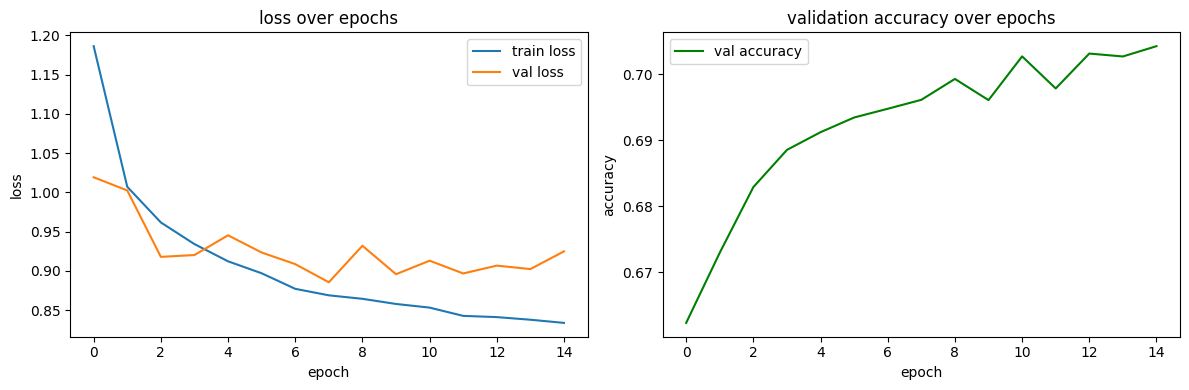

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='train loss')
ax1.plot(history['val_loss'], label='val loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_title('loss over epochs')
ax1.legend()

ax2.plot(history['val_acc'], label='val accuracy', color='green')
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.set_title('validation accuracy over epochs')
ax2.legend()

plt.tight_layout()
plt.show()

## 10. evaluate on test set

In [ ]:
model.load_state_dict(torch.load('best_star_model.pt', weights_only=True))
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_seq, batch_meta, batch_labels in test_loader:
        batch_seq = batch_seq.to(device)
        batch_meta = batch_meta.to(device)

        outputs = model(batch_seq, batch_meta)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(batch_labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

accuracy = (all_preds == all_true).mean()
print('test set results')
print('=' * 50)
print(f'accuracy: {accuracy:.4f}')
print()
print(classification_report(all_true, all_preds, target_names=['1 star', '2 star', '3 star', '4 star', '5 star']))

test set results
accuracy: 0.7024

              precision    recall  f1-score   support

      1 star       0.83      0.77      0.79      9367
      2 star       0.43      0.48      0.45      4943
      3 star       0.48      0.45      0.47      6534
      4 star       0.54      0.50      0.52     14312
      5 star       0.82      0.86      0.84     32814

    accuracy                           0.70     67970
   macro avg       0.62      0.61      0.61     67970
weighted avg       0.70      0.70      0.70     67970



In [ ]:
# how far off are the wrong predictions?
errors = all_preds - all_true
print('prediction error distribution (predicted - actual):')
print(f'  exact match:   {(errors == 0).mean():.2%}')
print(f'  off by 1 star: {(abs(errors) == 1).mean():.2%}')
print(f'  off by 2+:     {(abs(errors) >= 2).mean():.2%}')
print(f'  mean absolute error: {np.abs(errors).mean():.2f} stars')

prediction error distribution (predicted - actual):
  exact match:   70.24%
  off by 1 star: 26.15%
  off by 2+:     3.60%
  mean absolute error: 0.35 stars


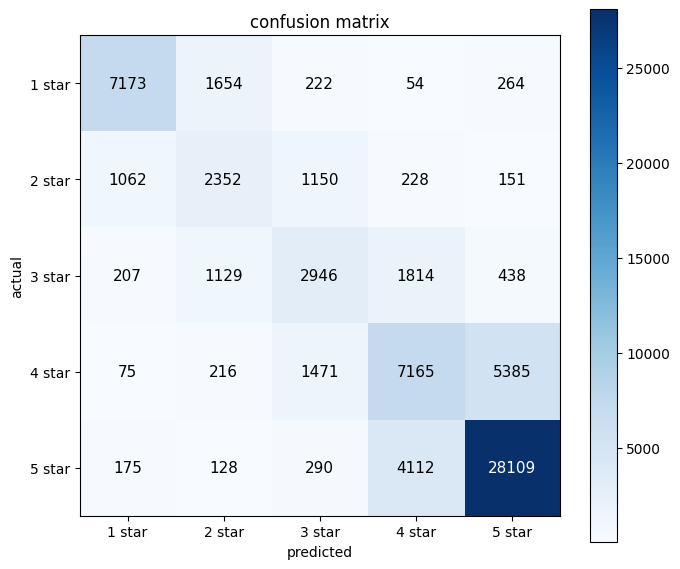

In [ ]:
# confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')

star_labels = ['1 star', '2 star', '3 star', '4 star', '5 star']
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(star_labels)
ax.set_yticklabels(star_labels)
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
ax.set_title('confusion matrix')

for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black', fontsize=11)

plt.colorbar(im)
plt.tight_layout()
plt.show()

## 11. detect mismatched reviews
reviews where the predicted rating is very different from what the user actually gave.
these are interesting -- could be sarcasm, accidental clicks, or unusual opinions.

In [ ]:
_, _, _, _, _, _, idx_train, idx_temp = train_test_split(
    sequences, meta_features, labels, np.arange(len(labels)),
    test_size=0.3, random_state=42, stratify=labels
)

_, _, _, _, _, _, idx_val, idx_test = train_test_split(
    seq_temp, meta_temp, y_temp, idx_temp,
    test_size=0.5, random_state=42, stratify=y_temp
)

# find reviews where prediction is off by 3+ stars
test_df = pdf.iloc[idx_test].reset_index(drop=True)
test_df['predicted_stars'] = all_preds + 1
test_df['actual_stars'] = all_true + 1
test_df['mismatch'] = abs(test_df['predicted_stars'] - test_df['actual_stars'])

mismatched = test_df[test_df['mismatch'] >= 3].sort_values('mismatch', ascending=False)
print(f'found {len(mismatched)} reviews with 3+ star mismatch\n')

for _, row in mismatched.head(5).iterrows():
    print(f'actual: {row["actual_stars"]:.0f} stars | predicted: {row["predicted_stars"]:.0f} stars | gap: {row["mismatch"]:.0f}')
    text = str(row.get('clean_text_no_stopwords', row.get('text', '')))
    print(f'text: {text[:150]}...')
    print()

found 847 reviews with 3+ star mismatch

actual: 5 stars | predicted: 1 stars | gap: 4
text: absolutely adore soulard spice shop variety spices reasonable prices make must visit stop stl could literally hours discovering different herbs spices...

actual: 1 stars | predicted: 5 stars | gap: 4
text: town holiday weekend due covid wanted decent take meal great go meal bistro clams appetizer amazing try clams places go broth clams one favorite bison...

actual: 5 stars | predicted: 1 stars | gap: 4
text: ok fat tuesday didnt go crazy tried doughnut shop close new job freshest yeastraised glazed donut long time delicious tonysdonuts mckelvey maryland he...

actual: 5 stars | predicted: 1 stars | gap: 4
text: waiting connection flight hour layover came across chickies petes omg food amazing wish waiter also bartender great answered questions made delish dri...

actual: 5 stars | predicted: 1 stars | gap: 4
text: food came around pm wednesday night seated right away table ordered broiled oys

In [ ]:
def text_to_seq(text, max_len=200):
    """Convert review text to a padded integer sequence."""
    tokens = text.lower().split()  # tokenize 
    seq = [vocab.get(token, vocab.get('<UNK>', 0)) for token in tokens]

    # Truncate or pad to max_len
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        pad_idx = vocab.get('<PAD>', 0)
        seq = seq + [pad_idx] * (max_len - len(seq))

    return seq

## 12. predict on new reviews

In [ ]:
def predict_stars(review_text, useful=0, funny=0, cool=0, word_count=None,
                  business_stars=3.5, review_count=100,
                  user_review_count=10, user_useful=5, user_funny=2, user_cool=1, is_open=1):
    model.eval()

    if word_count is None:
        word_count = len(review_text.split())

    seq = text_to_seq(review_text)
    seq_tensor = torch.LongTensor([seq]).to(device)

    meta = np.array([[useful, funny, cool, word_count, business_stars,
                      review_count, user_review_count, user_useful,
                      user_funny, user_cool, is_open]], dtype=np.float32)
    meta = scaler.transform(meta)
    meta_tensor = torch.FloatTensor(meta).to(device)

    with torch.no_grad():
        output = model(seq_tensor, meta_tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        predicted_class = output.argmax(dim=1).item()

    predicted_stars = predicted_class + 1
    print(f'predicted: {predicted_stars} stars')
    print(f'confidence: {probs[predicted_class]:.2%}')
    print(f'probabilities: ' + ' | '.join([f'{i+1}star:{p:.1%}' for i, p in enumerate(probs)]))
    return predicted_stars

In [ ]:
print('negative review:')
predict_stars('terrible food waited hour cold soggy fries rude waiter never coming back worst experience')

print()

print('positive review:')
predict_stars('amazing restaurant best steak ever cooked perfectly friendly staff beautiful atmosphere definitely coming back highly recommend')

print('mixed review:')
predict_stars('food decent nothing special service ok waited bit long prices fair location convenient probably average overall')

negative review:
predicted: 1 stars
confidence: 99.14%
probabilities: 1star:99.1% | 2star:0.9% | 3star:0.0% | 4star:0.0% | 5star:0.0%

positive review:
predicted: 5 stars
confidence: 97.94%
probabilities: 1star:0.0% | 2star:0.0% | 3star:0.0% | 4star:2.1% | 5star:97.9%
mixed review:
predicted: 3 stars
confidence: 88.83%
probabilities: 1star:0.0% | 2star:8.2% | 3star:88.8% | 4star:2.9% | 5star:0.0%


3

## 13. save model

In [ ]:
import pickle

torch.save(model.state_dict(), 'star_predictor_bilstm.pt')

artifacts = {
    'vocab': vocab,
    'scaler': scaler,
    'max_len': max_len,
    'feature_cols': feature_cols,
    'model_config': {
        'vocab_size': vocab_size,
        'embed_dim': embed_dim,
        'hidden_dim': hidden_dim,
        'num_meta_features': num_meta_features,
        'num_classes': num_classes,
        'dropout_rate': dropout_rate
    }
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('saved:')
print('  star_predictor_bilstm.pt (model weights)')
print('  model_artifacts.pkl (vocab, scaler, config)')
print('  best_star_model.pt (best checkpoint)')

saved:
  star_predictor_bilstm.pt (model weights)
  model_artifacts.pkl (vocab, scaler, config)
  best_star_model.pt (best checkpoint)
